# Three-Class Classification with a Bayesian Neural Network in Pyro and PyTorch

This notebook builds a simple **3-class classification problem** with a **4-dimensional feature vector** and solves it using a **Bayesian neural network (BNN)** trained with **stochastic variational inference (SVI)** in Pyro.

We will:

1. Create synthetic 4D data with three classes.
2. Define a neural network classifier.
3. Place prior distributions on every weight and bias.
4. Train an approximate posterior over the parameters using Pyro.
5. Visualize posterior distributions for selected parameters.
6. Estimate the posterior predictive distribution for test points.

The model is intentionally small so the Bayesian structure is easy to inspect.

## Mathematical setup

Each input is a vector

$$
\mathbf{x}_i \in \mathbb{R}^4,
$$

and each label is one of three classes:

$$
y_i \in \{0,1,2\}.
$$

We use a one-hidden-layer neural network. For a hidden width \(H\), the logits are


\begin{aligned}
\mathbf{h}_i &= \tanh(\mathbf{x}_i W_1 + \mathbf{b}_1), \\
\boldsymbol{\ell}_i &= \mathbf{h}_i W_2 + \mathbf{b}_2,
\end{aligned}

where

$$
W_1 \in \mathbb{R}^{4 \times H}, \quad
\mathbf{b}_1 \in \mathbb{R}^{H}, \quad
W_2 \in \mathbb{R}^{H \times 3}, \quad
\mathbf{b}_2 \in \mathbb{R}^{3}.
$$

The class probabilities are computed using the softmax function:

$$
p(y_i = k \mid \mathbf{x}_i, \theta) =
\frac{\exp(\ell_{ik})}{\sum_{j=0}^{2} \exp(\ell_{ij})}.
$$

For a Bayesian neural network, the weights and biases are random variables. We place independent Normal priors on all parameters:

$$
W_1, \mathbf{b}_1, W_2, \mathbf{b}_2 \sim \mathcal{N}(0, \sigma_{prior}^2).
$$

Pyro will learn an approximate posterior

$$
q(\theta) \approx p(\theta \mid X, y).
$$

The posterior predictive distribution for a new input \(\mathbf{x}_*\) is

$$
p(y_* \mid \mathbf{x}_*, X, y)
= \int p(y_* \mid \mathbf{x}_*, \theta) p(\theta \mid X, y)\, d\theta.
$$

We approximate this integral by drawing multiple parameter samples from the variational posterior and averaging the resulting class probabilities.

In [2]:
# If Pyro is not installed, uncomment the next line and run it once.
%pip install pyro-ppl

import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam
from pyro.nn import PyroModule, PyroSample

pyro.set_rng_seed(7)
torch.manual_seed(7)
np.random.seed(7)

print("PyTorch version:", torch.__version__)
print("Pyro version:", pyro.__version__)

   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---------------------------------------- 756.0/756.0 kB 8.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [pyro-ppl]
   -------------------- ------------------- 1/2 [pyro-ppl]
   -------------------- ------------------- 1/2 [pyro-ppl]
   -------------------- ------------------- 1/2 [pyro-ppl]
   -------------------- ------------------- 1/2 [pyro-ppl]
   -------------------- ------------------- 1/2 [pyro-ppl]
   -------------------- ------------------- 1/2 [pyro-ppl]
   ---------------------------------------- 2/2 [pyro-ppl]

Note: you may need to restart the kernel to use updated packages.
PyTorch version: 2.5.1
Pyro version: 1.9.1


## 1. Create a simple 4D, 3-class dataset

We generate data from three Gaussian clusters in \(\mathbb{R}^4\). Each class has a different mean vector and a shared covariance structure. This gives us a controlled classification problem where the input dimension is exactly four.

The classes are not made perfectly separable; a bit of overlap is useful because it lets the Bayesian neural network express meaningful predictive uncertainty.

In [3]:
def make_three_class_4d_data(n_per_class=120, noise_scale=0.75):
    """Create a synthetic 3-class dataset with 4 input features."""
    means = torch.tensor([
        [-2.0, -1.0,  0.5,  1.0],
        [ 2.0,  0.5, -1.0,  1.0],
        [ 0.0,  2.0,  1.5, -1.0],
    ])

    X_list, y_list = [], []
    for class_id, mean in enumerate(means):
        X_class = mean + noise_scale * torch.randn(n_per_class, 4)
        y_class = torch.full((n_per_class,), class_id, dtype=torch.long)
        X_list.append(X_class)
        y_list.append(y_class)

    X = torch.cat(X_list, dim=0)
    y = torch.cat(y_list, dim=0)

    # Shuffle examples.
    perm = torch.randperm(X.shape[0])
    X = X[perm]
    y = y[perm]

    return X, y

X, y = make_three_class_4d_data(n_per_class=140, noise_scale=0.85)

# Standardize features using the full dataset here for simplicity.
# In a production setting, fit normalization only on the training set.
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True)
X = (X - X_mean) / X_std

# Train/test split.
n_train = int(0.75 * X.shape[0])
X_train, y_train = X[:n_train], y[:n_train]
X_test, y_test = X[n_train:], y[n_train:]

print("X_train shape:", tuple(X_train.shape))
print("y_train shape:", tuple(y_train.shape))
print("X_test shape: ", tuple(X_test.shape))
print("y_test shape: ", tuple(y_test.shape))
print("Class counts in training set:", torch.bincount(y_train))

X_train shape: (315, 4)
y_train shape: (315,)
X_test shape:  (105, 4)
y_test shape:  (105,)
Class counts in training set: tensor([102, 106, 107])


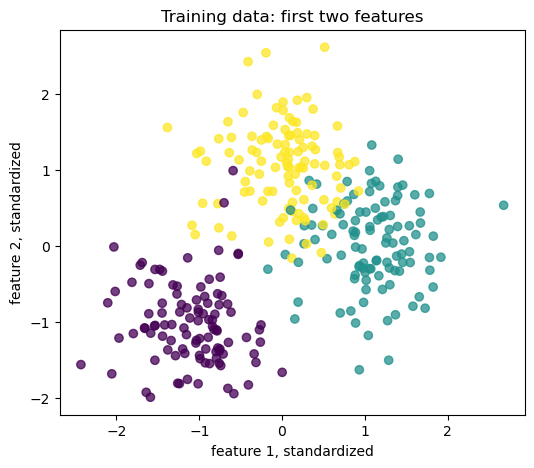

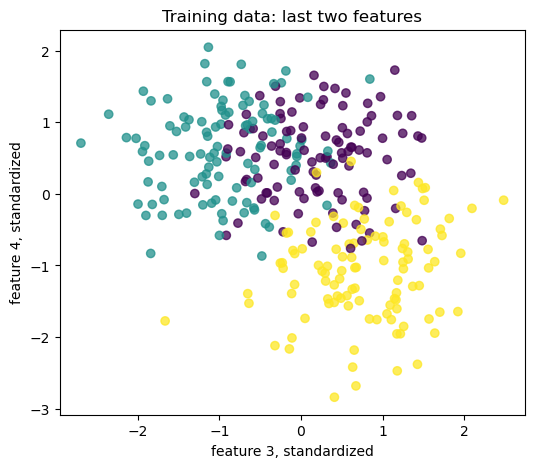

In [4]:
# Visualize two pairs of features. The model will still use all four features.
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, alpha=0.75)
ax.set_xlabel("feature 1, standardized")
ax.set_ylabel("feature 2, standardized")
ax.set_title("Training data: first two features")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X_train[:, 2], X_train[:, 3], c=y_train, alpha=0.75)
ax.set_xlabel("feature 3, standardized")
ax.set_ylabel("feature 4, standardized")
ax.set_title("Training data: last two features")
plt.show()

## 2. Define the Bayesian neural network

A regular neural network stores deterministic weights and biases. A Bayesian neural network instead treats them as random variables.

Pyro's `PyroModule` and `PyroSample` make this convenient. Each layer below has a prior distribution for its weights and biases.

We use independent Normal priors:


\begin{aligned}
W_1 &\sim \mathcal{N}(0, 1), & \mathbf{b}_1 &\sim \mathcal{N}(0, 1), \\
W_2 &\sim \mathcal{N}(0, 1), & \mathbf{b}_2 &\sim \mathcal{N}(0, 1), \\
W_3 &\sim \mathcal{N}(0, 1), & \mathbf{b}_3 &\sim \mathcal{N}(0, 1).

\end{aligned}


The `.to_event(...)` calls tell Pyro how many dimensions belong to a single random variable rather than to independent batch observations.

In [20]:
class BayesianClassifier(PyroModule):
    def __init__(self, input_dim=4, hidden_dim=8, output_dim=3, prior_scale=1.0):
        super().__init__()

        self.fc1 = PyroModule[nn.Linear](input_dim, hidden_dim)
        self.fc1.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([hidden_dim, input_dim]).to_event(2)
        )
        self.fc1.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([hidden_dim]).to_event(1)
        )

        self.fc2 = PyroModule[nn.Linear](hidden_dim, hidden_dim)
        self.fc2.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([hidden_dim, hidden_dim]).to_event(2)
        )
        self.fc2.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([hidden_dim]).to_event(1)
        )

        self.fc3 = PyroModule[nn.Linear](hidden_dim, output_dim)
        self.fc3.weight = PyroSample(
            dist.Normal(0.0, prior_scale).expand([output_dim, hidden_dim]).to_event(2)
        )
        self.fc3.bias = PyroSample(
            dist.Normal(0.0, prior_scale).expand([output_dim]).to_event(1)
        )

    def forward(self, x, y=None):
        hidden1 = torch.tanh(self.fc1(x))
        hidden2 = torch.tanh(self.fc2(hidden1))
        
        logits = self.fc3(hidden2)

        with pyro.plate("data", x.shape[0]):
            obs = pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

        return logits

model = BayesianClassifier(input_dim=4, hidden_dim=8, output_dim=3, prior_scale=2.0)
print(model)

BayesianClassifier(
  (fc1): PyroLinear(in_features=4, out_features=8, bias=True)
  (fc2): PyroLinear(in_features=8, out_features=8, bias=True)
  (fc3): PyroLinear(in_features=8, out_features=3, bias=True)
)


## 3. Define the variational posterior with `AutoDiagonalNormal`

The true posterior over neural network parameters is usually not available in closed form. Pyro therefore uses variational inference.

We choose a diagonal Normal variational family:

$$
q(\theta) = \mathcal{N}(\boldsymbol{\mu}, \operatorname{diag}(\boldsymbol{\sigma}^2)).
$$

This means Pyro learns a mean and standard deviation for every latent parameter in the BNN. This is less expressive than a full covariance posterior, but it is simple, fast, and easy to visualize.

In [21]:
from pyro.infer.autoguide import AutoDiagonalNormal

pyro.clear_param_store()
guide = AutoDiagonalNormal(model)

# Run once to initialize guide parameters.
_ = guide(X_train[:5], y_train[:5])

for name, value in pyro.get_param_store().items():
    print(f"{name:40s} {tuple(value.shape)}")

AutoDiagonalNormal.loc                   (139,)
AutoDiagonalNormal.scale                 (139,)


## 4. Train with stochastic variational inference

SVI maximizes the evidence lower bound, or ELBO:

$$
\mathcal{L}(q)
= \mathbb{E}_{q(\theta)}[\log p(y \mid X, \theta)]
- \operatorname{KL}(q(\theta) \Vert p(\theta)).
$$

Equivalently, it minimizes the negative ELBO. The first term encourages good classification performance. The KL term keeps the posterior from drifting too far from the prior unless the data support it.

In [22]:
def train_bnn(model, guide, X_train, y_train, num_steps=2500, lr=0.01):
    pyro.clear_param_store()
    guide = AutoDiagonalNormal(model)
    optimizer = Adam({"lr": lr})
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_train, y_train)
        losses.append(loss / X_train.shape[0])

        if (step + 1) % 500 == 0:
            print(f"step {step + 1:4d} | loss per data point = {losses[-1]:.4f}")

    return guide, losses

guide, losses = train_bnn(
    model=model,
    guide=guide,
    X_train=X_train,
    y_train=y_train,
    num_steps=5000,
    lr=0.01,
)

step  500 | loss per data point = 0.5075
step 1000 | loss per data point = 0.3782
step 1500 | loss per data point = 0.3950
step 2000 | loss per data point = 0.3648
step 2500 | loss per data point = 0.3709
step 3000 | loss per data point = 0.3348
step 3500 | loss per data point = 0.3853
step 4000 | loss per data point = 0.3424
step 4500 | loss per data point = 0.3126
step 5000 | loss per data point = 0.3905


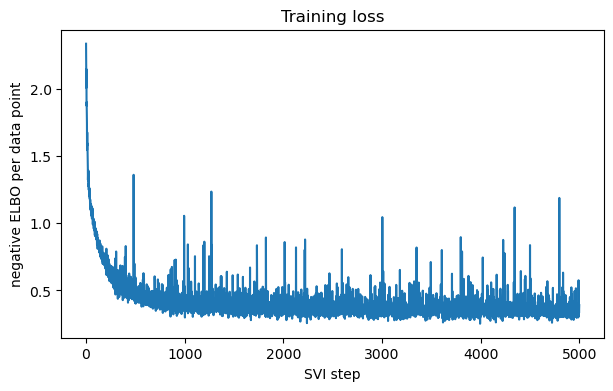

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses)
ax.set_xlabel("SVI step")
ax.set_ylabel("negative ELBO per data point")
ax.set_title("Training loss")
plt.show()

## 5. Posterior samples for weights and biases

After training, the guide defines an approximate posterior distribution over all neural network parameters.

We draw many samples from this posterior and inspect selected weights and biases. A narrow posterior indicates the data identified that parameter relatively strongly. A wider posterior indicates more uncertainty.

In [24]:
def collect_posterior_samples(model, guide, num_samples=1000):
    predictive = Predictive(model, guide=guide, num_samples=num_samples, return_sites=(
        "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias"
    ))
    samples = predictive(X_train[:1], None)
    return {k: v.detach().cpu() for k, v in samples.items()}

posterior_samples = collect_posterior_samples(model, guide, num_samples=1000)

for name, values in posterior_samples.items():
    print(f"{name:12s} shape: {tuple(values.shape)}")

fc1.weight   shape: (1000, 1, 8, 4)
fc1.bias     shape: (1000, 1, 8)
fc2.weight   shape: (1000, 1, 8, 8)
fc2.bias     shape: (1000, 1, 8)


In [27]:
print(np.shape(posterior_samples["fc1.weight"]))

torch.Size([1000, 1, 8, 4])


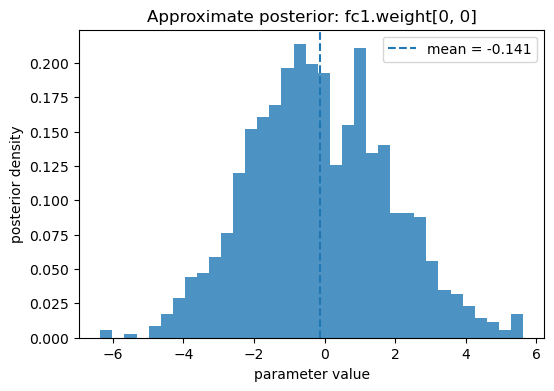

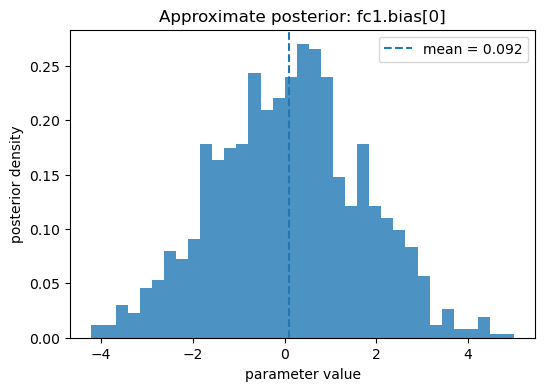

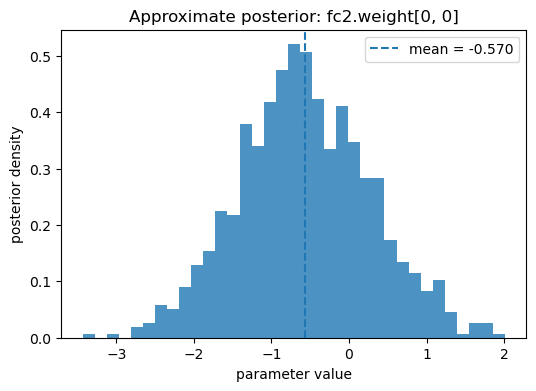

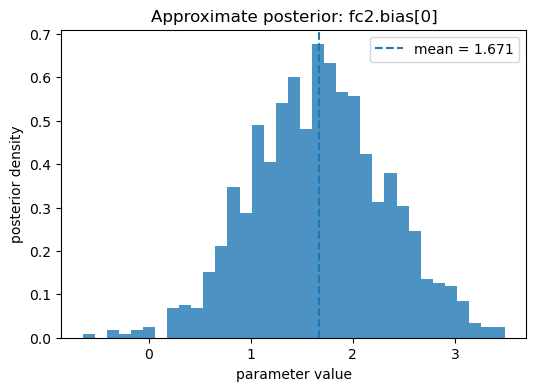

In [29]:
# Plot posterior histograms for a few representative parameters.
selected_params = {
    "fc1.weight[0, 0]": posterior_samples["fc1.weight"][:, 0, 0, 0].numpy(),
    "fc1.bias[0]": posterior_samples["fc1.bias"][:,0, 0].numpy(),
    "fc2.weight[0, 0]": posterior_samples["fc2.weight"][:, 0, 0, 0].numpy(),
    "fc2.bias[0]": posterior_samples["fc2.bias"][:, 0, 0].numpy(),
}

for name, values in selected_params.items():
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(values, bins=35, density=True, alpha=0.8)
    ax.axvline(values.mean(), linestyle="--", label=f"mean = {values.mean():.3f}")
    ax.set_xlabel("parameter value")
    ax.set_ylabel("posterior density")
    ax.set_title(f"Approximate posterior: {name}")
    ax.legend()
    plt.show()

## 6. Posterior predictive distribution

For classification, one posterior sample of the neural-network parameters gives one probability vector:

$$
\operatorname{softmax}(f_\theta(\mathbf{x}_*)).
$$

The Bayesian prediction averages over many such parameter samples:

$$
\hat{p}(y_* = k \mid \mathbf{x}_*, X, y)
\approx
\frac{1}{S}\sum_{s=1}^{S}
\operatorname{softmax}(f_{\theta^{(s)}}(\mathbf{x}_*))_k.
$$

This average gives both a prediction and an uncertainty estimate. When different posterior samples disagree, the predictive distribution is less concentrated.

In [30]:
def posterior_predictive_probs(model, guide, X_new, num_samples=500):
    predictive = Predictive(model, guide=guide, num_samples=num_samples, return_sites=("_RETURN",))
    sampled_logits = predictive(X_new, None)["_RETURN"]
    # sampled_logits has shape [num_samples, n_points, n_classes]
    sampled_probs = torch.softmax(sampled_logits, dim=-1)
    mean_probs = sampled_probs.mean(dim=0)
    std_probs = sampled_probs.std(dim=0)
    return mean_probs.detach(), std_probs.detach(), sampled_probs.detach()

mean_probs, std_probs, sampled_probs = posterior_predictive_probs(model, guide, X_test, num_samples=800)
y_pred = mean_probs.argmax(dim=1)
accuracy = (y_pred == y_test).float().mean().item()

print(f"Test accuracy from posterior mean probabilities: {accuracy:.3f}")
print("First five predictive mean probabilities:")
print(mean_probs[:5])
print("First five true labels:", y_test[:5].tolist())

Test accuracy from posterior mean probabilities: 0.981
First five predictive mean probabilities:
tensor([[9.8990e-01, 6.9813e-03, 3.1145e-03],
        [7.1723e-04, 9.1445e-01, 8.4835e-02],
        [9.8755e-01, 4.8002e-03, 7.6542e-03],
        [8.1987e-01, 1.7516e-01, 4.9691e-03],
        [2.2647e-03, 5.3346e-03, 9.9240e-01]])
First five true labels: [0, 1, 0, 0, 2]


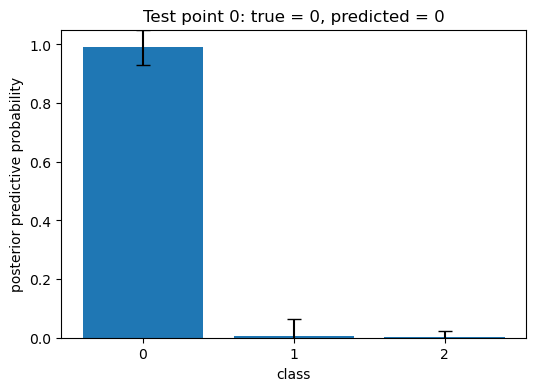

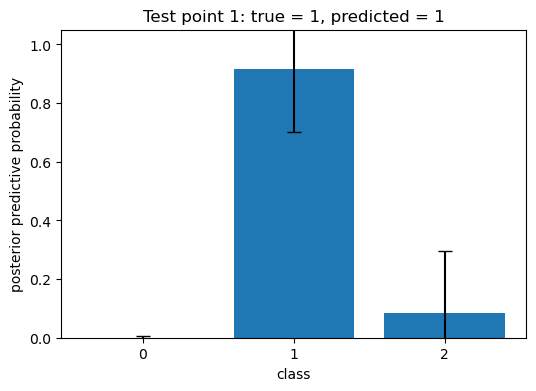

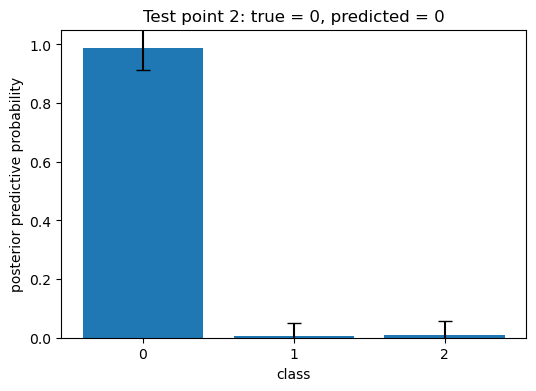

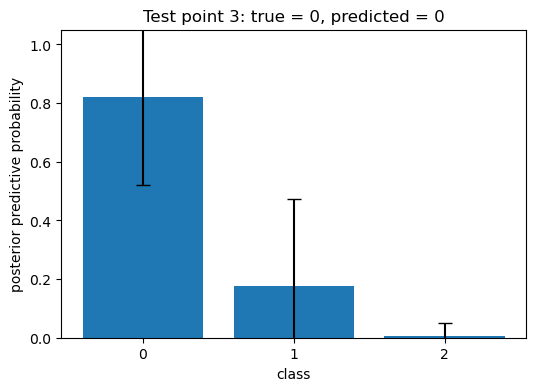

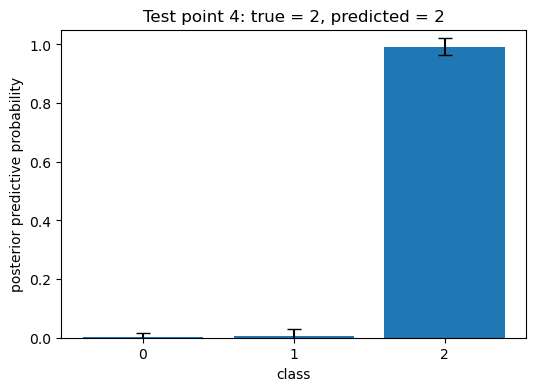

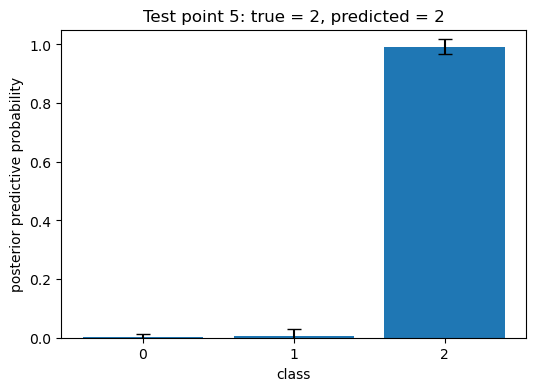

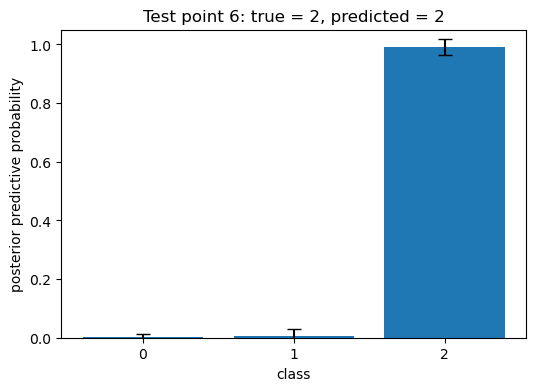

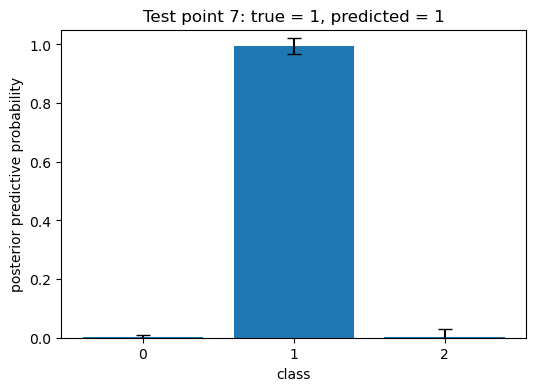

In [31]:
# Plot predictive distributions for several individual test points.
num_examples_to_plot = 8
indices = torch.arange(num_examples_to_plot)

for idx in indices:
    probs = mean_probs[idx].numpy()
    errs = std_probs[idx].numpy()
    true_label = int(y_test[idx])
    pred_label = int(y_pred[idx])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([0, 1, 2], probs, yerr=errs, capsize=5)
    ax.set_xticks([0, 1, 2])
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("class")
    ax.set_ylabel("posterior predictive probability")
    ax.set_title(f"Test point {int(idx)}: true = {true_label}, predicted = {pred_label}")
    plt.show()

## 7. Predictive uncertainty summary

A useful uncertainty measure for classification is the entropy of the predictive probability vector:

$$
H[p] = -\sum_{k=0}^{2} p_k \log p_k.
$$

Low entropy means the model is confident. High entropy means the probability mass is spread across classes.

In [32]:
def entropy(probs, eps=1e-12):
    return -(probs * torch.log(probs + eps)).sum(dim=-1)

pred_entropy = entropy(mean_probs)
confidence = mean_probs.max(dim=1).values

summary = pd.DataFrame({
    "true_label": y_test.numpy(),
    "pred_label": y_pred.numpy(),
    "confidence": confidence.numpy(),
    "entropy": pred_entropy.numpy(),
    "p_class_0": mean_probs[:, 0].numpy(),
    "p_class_1": mean_probs[:, 1].numpy(),
    "p_class_2": mean_probs[:, 2].numpy(),
})

summary.head(10)

,true_label,pred_label,confidence,entropy,p_class_0,p_class_1,p_class_2
0,0,0,0.989904,0.062679,0.989904,0.006981,0.003114
1,1,1,0.914448,0.296267,0.000717,0.914448,0.084835
2,0,0,0.987546,0.075301,0.987546,0.004800,0.007654
3,0,0,0.819871,0.494330,0.819871,0.175160,0.004969
4,2,2,0.992401,0.049282,0.002265,0.005335,0.992401
5,2,2,0.992675,0.047632,0.002027,0.005298,0.992675
6,2,2,0.992449,0.048989,0.002219,0.005331,0.992449
7,1,1,0.994957,0.034683,0.001399,0.994957,0.003644
8,2,2,0.988476,0.070881,0.005727,0.005797,0.988476
9,1,1,0.967406,0.148395,0.001082,0.967406,0.031512


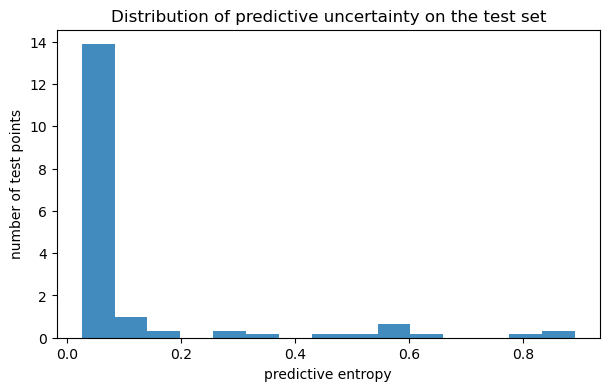

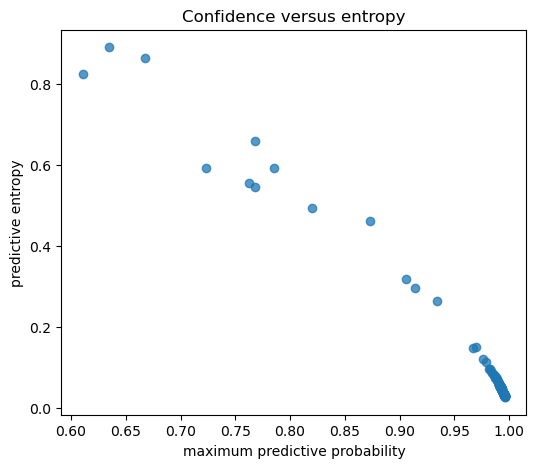

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pred_entropy.numpy(), bins=15, alpha=0.85, density=True)
ax.set_xlabel("predictive entropy")
ax.set_ylabel("number of test points")
ax.set_title("Distribution of predictive uncertainty on the test set")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(confidence.numpy(), pred_entropy.numpy(), alpha=0.75)
ax.set_xlabel("maximum predictive probability")
ax.set_ylabel("predictive entropy")
ax.set_title("Confidence versus entropy")
plt.show()

## 8. Optional: inspect the most uncertain test examples

The examples with the largest entropy are the points where the model is least certain. In real applications, these are useful candidates for additional labeling, data inspection, or abstention.

In [37]:
summary.sort_values("entropy", ascending=False).head(10)

,true_label,pred_label,confidence,entropy,p_class_0,p_class_1,p_class_2
55,1,1,0.634801,0.890544,0.124298,0.634801,0.240901
14,0,0,0.667690,0.863978,0.667690,0.147211,0.185099
57,2,2,0.610471,0.824901,0.335752,0.053777,0.610471
99,0,0,0.768070,0.659431,0.768070,0.047683,0.184247
62,0,0,0.785659,0.593123,0.785659,0.191146,0.023196
41,1,1,0.723482,0.592337,0.000353,0.723482,0.276165
82,1,1,0.762690,0.555528,0.001205,0.762690,0.236105
76,1,1,0.767714,0.544831,0.000378,0.767714,0.231908
3,0,0,0.819871,0.494330,0.819871,0.175160,0.004969
75,2,0,0.872785,0.460215,0.872785,0.039939,0.087276


## What this notebook demonstrated

- The input data are 4D vectors with labels from 3 classes.
- The classifier is a one-hidden-layer neural network.
- Every weight and bias has a Normal prior.
- Pyro's `AutoDiagonalNormal` guide learns an approximate posterior over all weights and biases.
- Posterior samples give uncertainty over parameters.
- Averaging predictions across posterior samples gives the posterior predictive distribution.
- Predictive entropy gives a simple scalar summary of classification uncertainty.

Possible extensions:

- Use a richer guide such as `AutoMultivariateNormal`.
- Increase the hidden width or add another hidden layer.
- Compare Bayesian uncertainty to dropout or ensemble uncertainty.
- Use minibatching for larger datasets.